## Bacteria Exploratory Data Analysis

### Segment into Kmers & Heatmap
Done using manipulations.py > fasta_to_kmerdf

In [ ]:
import pandas as pd
from Bio import SeqIO
import numpy as np
import os, sys
from tqdm import tqdm

raw_data_path = "../raw_data/"
data_prod_path = "../data_prod/"
scripts_path = "../scripts/"

sys.path.append(scripts_path)
print(sys.path)

from manipulations import fasta_to_kmerdf
from io_operations import presence_matrix

### Obtaining kmers from MinHashes

In [ ]:
from sourmash import load_one_signature
sig0 = load_one_signature("../data_prod/bact_minhash_37/bact0.sig", ksize=37, select_moltype='DNA')
with open("../tmp/inspect_sig0.txt", "w") as f:
    f.write(str(sig0.minhash.hashes.keys()))  # Write the keys to a file for inspection


### Clustering strains

In [ ]:
import sourmash
from Bio import SeqIO
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
n = 500
k = 12
#prev_gen = data_prod_path+"bact_clusters.csv"
prev_gen = None

if prev_gen is None:
    records = list(SeqIO.parse(raw_data_path+"phagehost_KU/bacteriaKU_cleaned.fasta", "fasta"))
    #Constructing minhashes for all records
    minhashes = []
    for rec in tqdm(records, desc="Constructing minhashes for all records", unit="seq"):
        #print("Record:", rec.id, len(rec.seq))
        mh = sourmash.MinHash(n=n, ksize=k) #each record gets its own minhash
        for i in range(0, len(rec.seq) - k + 1):
            kmer = str(rec.seq[i:i+k])
            mh.add_sequence(kmer, force=True)
        minhashes.append(mh)

    #Comparing all minhashes
    similarity_matrix = dict()
    for i, e in enumerate(minhashes):
        sim_inner = dict()
        for j, e2 in enumerate(minhashes):
            x = e.jaccard(minhashes[j])
            sim_inner[records[j].id] = x
        similarity_matrix[records[i].id] = sim_inner

    similarity_matrix
    similarity_matrix_df = pd.DataFrame(similarity_matrix)
    similarity_matrix_df.to_csv("../data_prod/bact_similarity_matrix.csv")

else:
    results = pd.read_csv(prev_gen, index_col=0)
    similarity_matrix_df = pd.read_csv("../data_prod/bact_similarity_matrix.csv", index_col=0)

In [ ]:
if prev_gen is None:
    sim_df = pd.DataFrame(similarity_matrix)
    sim_df.head()

In [ ]:
if prev_gen is None:
    # set a seed for reproducibility
    np.random.seed(42)
    from sklearn.cluster import AgglomerativeClustering
    cluster_sim = 0.95

    # We convert similarity to 'distance' (Distance = 1 - Similarity)
    df_dist = 1 - sim_df

    # 2. Initialize the clusterer
    # 'distance_threshold' is your similarity cutoff
    # 'n_clusters=None' is required when using a distance threshold
    model = AgglomerativeClustering(
        metric='precomputed', 
        linkage='average', 
        distance_threshold=1 - cluster_sim,
        n_clusters=None
    )

    # 3. Fit and get labels
    cluster_labels = model.fit_predict(df_dist)

    # 4. Add labels back to your index
    results = pd.DataFrame(cluster_labels, index=sim_df.index, columns=['Cluster']).sort_values(by='Cluster')
    print(results)

    results.to_csv("../data_prod/bact_clusters.csv")

Appending most common genus for cluster

In [ ]:
from io_operations import call_hostrange_df
bact_lookup, host_range_df = call_hostrange_df(os.path.join(raw_data_path, "phagehost_KU/Hostrange_data_all_crisp_iso.xlsx"))
print(bact_lookup)
strain_names = list(bact_lookup.keys())
genus_names = list(bact_lookup.values())
bact_lookup_df = pd.DataFrame({"strain": strain_names, "genus": genus_names})
bact_lookup_df.set_index("strain", inplace=True)
display(results)
display(bact_lookup_df)
#merge results with bact_lookup 
results = results.merge(bact_lookup_df, left_index=True, right_index=True, how="left")
display(results.head())

In [ ]:
#Majority cluster genus
cluster_genus = results.groupby("Cluster")["genus"].agg(lambda x: x.mode()[0] if not x.mode().empty else "Unknown")
#display(cluster_genus)

# Append to the results dataframe
results["Cluster_Genus"] = results["Cluster"].map(cluster_genus)
display(results)

results.to_csv("../data_prod/bact_clusters_with_genus.csv")

In [ ]:
results_invest = results[["Cluster", "Cluster_Genus"]].copy()
#aggregate by cluste
cluster_genera_counts = results_invest.groupby("Cluster")["Cluster_Genus"].value_counts()
display(cluster_genera_counts)
print([f"{genus} (Cluster: {cluster})" for cluster, genus in cluster_genera_counts.index.tolist()])

In [ ]:
from manipulations import short_species_name

# Sort away cluster size < 2
#results_sub = results[results['Cluster'].map(results['Cluster'].value_counts()) > 1]
results_sub = results.groupby(["Cluster", "Cluster_Genus"]).size()
display(results_sub)

fig = plt.figure(figsize=(10, 6))
sns.countplot(x=results_sub["0"], order=results_sub["0"].value_counts().index)
plt.xticks(rotation=90)
#append corresponding cluster number to x-axis labels
plt.xticks(ticks=range(len(results_sub)), labels=[f"{genus} (Cluster: {cluster})" for cluster, genus in results_sub.index.tolist()], rotation=90, size=8)
plt.xlabel('Cluster Label')
plt.ylabel('Count (Total: {})'.format(len(results_sub)))
plt.title('Bacteria Cluster Size Distribution (Excluding Singletons)')
#plt.savefig("../data_prod/bact_cluster_size_distribution.png", bbox_inches='tight')
plt.show()

In [ ]:
#Relate clustering back to similarity matrix heatmap
# Cluster color palette
unique_clusters = results['Cluster'].unique()
colors = sns.color_palette("hls", len(unique_clusters))
cluster_color_map = dict(zip(unique_clusters, colors))

fig = plt.figure(figsize=(10, 10))
g = sns.clustermap(pd.DataFrame(similarity_matrix).T, cmap="viridis")
ax = g.ax_heatmap

ax.set_xticks(np.arange(len(g.data2d.columns)) + 0.5)
ax.set_yticks(np.arange(len(g.data2d.index)) + 0.5)
ax.set_xticklabels(g.data2d.columns, fontsize=4)
ax.set_yticklabels(g.data2d.index, fontsize=4)

# 1. Update X-axis labels (Columns)
for tick_label in ax.get_xticklabels():
    bact_name = tick_label.get_text()
    if bact_name in results.index:
        cluster_val = results.loc[bact_name, 'Cluster']
        tick_label.set_color(cluster_color_map[cluster_val])

# 2. Update Y-axis labels (Rows)
for tick_label in ax.get_yticklabels():
    bact_name = tick_label.get_text()
    if bact_name in results.index:
        cluster_val = results.loc[bact_name, 'Cluster']
        tick_label.set_color(cluster_color_map[cluster_val])

plt.title('Bacteria Similarity Matrix with Clustered Labels')
plt.savefig(data_prod_path+"bact_similarity_matrix_clustermap.png", bbox_inches='tight')
plt.show()

#### Visualize clustering against hostrange data

In [ ]:
from io_operations import call_hostrange_df
bact_lookup, host_range_df = call_hostrange_df(raw_data_path + "phagehost_KU/Hostrange_data_all_crisp_iso.xlsx")
print(bact_lookup)
display(host_range_df)

In [ ]:
from manipulations import hostrange_df_to_dict, binarize_host_range

# Convert the host range data into a dictionary
host_range_data = hostrange_df_to_dict(host_range_df)
host_range_data = binarize_host_range(host_range_data, continous=False) #for classification model
host_range_data = pd.DataFrame(host_range_data).T
host_range_data

In [ ]:
### Sort the y-axis of the host range heatmap according to the clustering results
sorted_bacteria = results.sort_values('Cluster').index.tolist()
host_range_data = host_range_data.reindex(sorted_bacteria)

### Plotting
fig = plt.figure(figsize=(12, 8))
ax = sns.heatmap(host_range_data, cmap="YlGnBu")

ax.set_xticks(np.arange(len(host_range_data.columns)) + 0.5)
ax.set_yticks(np.arange(len(host_range_data.index)) + 0.5)
ax.set_xticklabels(host_range_data.columns, fontsize=6)
ax.set_yticklabels(host_range_data.index, fontsize=4)

# 1. Update X-axis labels (Columns)
for tick_label in ax.get_xticklabels():
    bact_name = tick_label.get_text()
    if bact_name in results.index:
        cluster_val = results.loc[bact_name, 'Cluster']
        tick_label.set_color(cluster_color_map[cluster_val])

# 2. Update Y-axis labels (Rows)
for tick_label in ax.get_yticklabels():
    bact_name = tick_label.get_text()
    if bact_name in results.index:
        cluster_val = results.loc[bact_name, 'Cluster']
        tick_label.set_color(cluster_color_map[cluster_val])

plt.title('Binarized Hostrange Heatmap with Clustered Bact Label Colors')
plt.savefig(data_prod_path+"bact_hostrange_heatmap.png", bbox_inches='tight')
plt.show()

## Host range fix with PFI

In [1]:
import os
from paths import raw_data_path
from io_operations import call_hostrange_df
from manipulations import hostrange_df_to_dict, hostrange_bact, clean_bact_names
bact_lookup, host_range_df = call_hostrange_df(os.path.join(raw_data_path, "phagehost_KU/Hostrange_data_all_crisp_iso.xlsx"))
host_range_data = hostrange_df_to_dict(host_range_df)


#host_range_df["phage"] = host_range_df["phage"].apply(lambda x: clean_bact_names(x))  # Keep only the first word of the phage name
display(host_range_df.head())


# cleaned_hostrange = {
#     clean_bact_names(bact): interactions
#     for bact, interactions in host_range_data.items()
# }
# print(cleaned_hostrange.keys())

,phage,Ymer,Taid,Poppous,Koroua,Abuela,Amona,Sabo,Mimer,Crus,...,Vims,Echoes,Galvinrad,Uther,Rip,Rup,Slaad,Pantea,Rap,Zann
0,J14_21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,J53_21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,J105_22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,J46_21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,J50_21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
#print("Host range data not provided, calling hostrange_bact to obtain host range data for bacteria names...")
host_range_data_out = {}
bact_names = ['J28_21', 'J33_21']
for bact in bact_names:
    host_range_data_out[bact] = hostrange_bact(host_range_data, [bact], approach="acceptive", threshold=0.5, TS = False)

host_range_data = {bact.replace("_reoriented", ""): interactions for bact, interactions in host_range_data_out.items()} # if "_reoriented" is in the bacteria names in host_range_data, remove it to match the bacteria names in the presence matrix.
host_range_data

{'J28_21': {'Ymer': np.float64(0.0),
  'Taid': np.float64(0.0),
  'Poppous': np.float64(0.0),
  'Koroua': np.float64(0.0),
  'Abuela': np.float64(0.0),
  'Amona': np.float64(0.0),
  'Sabo': np.float64(0.0),
  'Mimer': np.float64(0.0),
  'Crus': np.float64(0.0),
  'Gander': np.float64(0.0),
  'Guf': np.float64(0.0),
  'Hoejben': np.float64(0.0),
  'Magnum': np.float64(0.0),
  'Vims': np.float64(0.0),
  'Echoes': np.float64(0.0),
  'Galvinrad': np.float64(0.0),
  'Uther': np.float64(0.0),
  'Rip': np.float64(0.0),
  'Rup': np.float64(0.0),
  'Slaad': np.float64(0.0),
  'Pantea': np.float64(0.0),
  'Rap': np.float64(0.0),
  'Zann': np.float64(0.0)},
 'J33_21': {'Ymer': np.float64(0.0),
  'Taid': np.float64(0.0),
  'Poppous': np.float64(0.0),
  'Koroua': np.float64(0.0),
  'Abuela': np.float64(0.0),
  'Amona': np.float64(0.0),
  'Sabo': np.float64(0.0),
  'Mimer': np.float64(0.0),
  'Crus': np.float64(0.0),
  'Gander': np.float64(0.0),
  'Guf': np.float64(0.0),
  'Hoejben': np.float64(0.0)

In [14]:
import numpy as np
type(host_range_data["J28_21"]["Abuela"]) == np.float64

True

In [19]:
from analysis import get_strain_name
from collections import defaultdict

hash_lookup = defaultdict(set)

hash_lookup["bkmer123"].add("J14_21")
hash_lookup["bkmer123"].add("J26_21")
hash_lookup["bkmer456"].add("J14_21")

print(hash_lookup)
print(hash_lookup["bkmer123"])
get_strain_name("bkmer123", hash_lookup)

defaultdict(<class 'set'>, {'bkmer123': {'J26_21', 'J14_21'}, 'bkmer456': {'J14_21'}})
{'J26_21', 'J14_21'}


'bkmer123'

## Bact Statistics

### Bacteria genome size distribution - data1 and data2

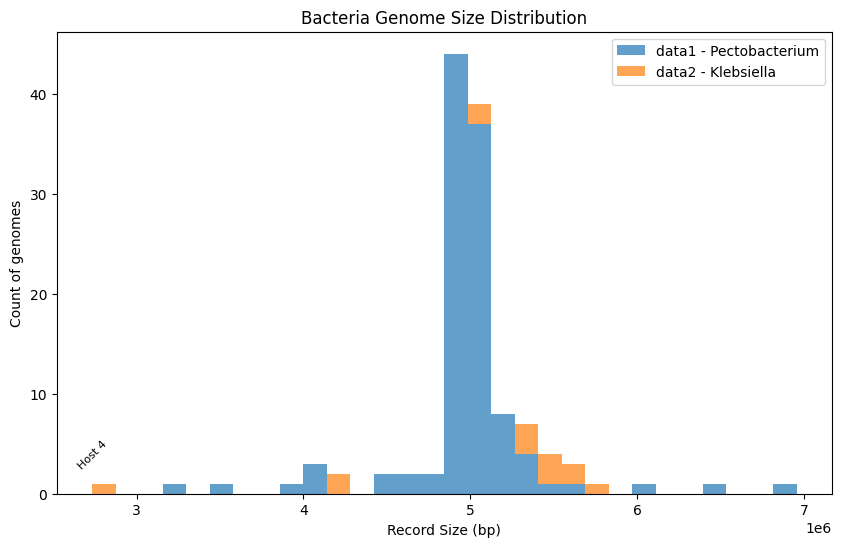

In [1]:
from Bio import SeqIO
import os, re
import matplotlib.pyplot as plt
import seaborn as sns
from paths import raw_data_path
from manipulations import clean_bact_names

path_to_bact_fasta = raw_data_path+"phagehost_KU/concatenated_bacteria/"
bact_files = os.listdir(path_to_bact_fasta)
records_dataset1 = [record for f in bact_files for record in SeqIO.parse(os.path.join(path_to_bact_fasta, f), "fasta")]
records_dataset1 = [record for record in records_dataset1]
for record in records_dataset1:
    cleaned_id = clean_bact_names(record.id)
    record.id = cleaned_id

records_dataset2 = list(SeqIO.parse(raw_data_path+"phagehost_KU/data2_bacts.fasta", "fasta"))
for record in records_dataset2:
    try:
        cleaned_id = clean_bact_names(record.id, data2=True)
    except Exception as e:
        # extract Kp_KU7_circular_bp=206344_linear_bp=5324540 as Host 7
        reg_pattern = r"Kp_KU(\d+)_circular_bp=\d+_linear_bp=\d+"
        match = re.search(reg_pattern, record.id)
        if match:
            cleaned_id = f"Host {match.group(1)}"
        else:
            cleaned_id = record.id  # fallback to original ID if pattern doesn't match
    record.id = cleaned_id

records = [records_dataset1, records_dataset2]

def plot_record_size_distribution(records, title="Distribution of Record Sizes"):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    if len(records) == 2:
        labels = ["data1 - Pectobacterium", "data2 - Klebsiella"]
        record_sizes_list = []
        for i, record_set in enumerate(records):
            record_sizes = [len(rec.seq) for rec in record_set]
            record_sizes_list.append(record_sizes)
        
        # Create stacked histogram
        ax.hist(record_sizes_list, bins=30, label=labels, stacked=True, alpha=0.7)
    elif len(records) == 1:
        record_sizes = [len(rec.seq) for rec in records[0]]
        sns.histplot(record_sizes, bins=30, kde=True, label="Dataset", ax=ax, alpha=0.6)
    else:
        raise ValueError("Expected 1 or 2 sets of records, got {}".format(len(records)))
    
    # Annotate small records across all datasets
    for record_set in records:
        for rec in record_set:
            seq_len = len(rec.seq)
            if seq_len < 3000000: 
                ax.annotate(
                    rec.id,
                    xy=(seq_len, 0),
                    xytext=(seq_len, ax.get_ylim()[1] * 0.05),  # slight offset from x-axis
                    rotation=45,
                    fontsize=8,
                    ha="center",
                    va="bottom"
                )


    ax.set_title(title)
    ax.set_xlabel("Record Size (bp)")
    ax.set_ylabel("Count of genomes")
    ax.legend()
    plt.savefig("../fig/bacteria_genome_size_distribution.png", dpi=300)
    plt.show()

plot_record_size_distribution(records, "Bacteria Genome Size Distribution")

Annotating J63_22 with GC content 36.10% (Bin 6, annotated 0 times before)
Annotating J105_22 with GC content 28.25% (Bin 0, annotated 0 times before)
Annotating J14_21 with GC content 38.71% (Bin 9, annotated 0 times before)
Annotating J5_21 with GC content 32.58% (Bin 3, annotated 0 times before)
Annotating J2264_3 with GC content 36.18% (Bin 6, annotated 1 times before)
Annotating J109_23 with GC content 62.45% (Bin 29, annotated 0 times before)
Annotating J64_22 with GC content 36.09% (Bin 6, annotated 2 times before)
Annotating J2264_1 with GC content 36.10% (Bin 6, annotated 3 times before)
Annotating J46_21 with GC content 36.10% (Bin 6, annotated 4 times before)
Annotating J53_21 with GC content 38.75% (Bin 9, annotated 1 times before)
Annotating J101_22 with GC content 60.63% (Bin 28, annotated 0 times before)
Annotating J50_21 with GC content 36.11% (Bin 6, annotated 5 times before)


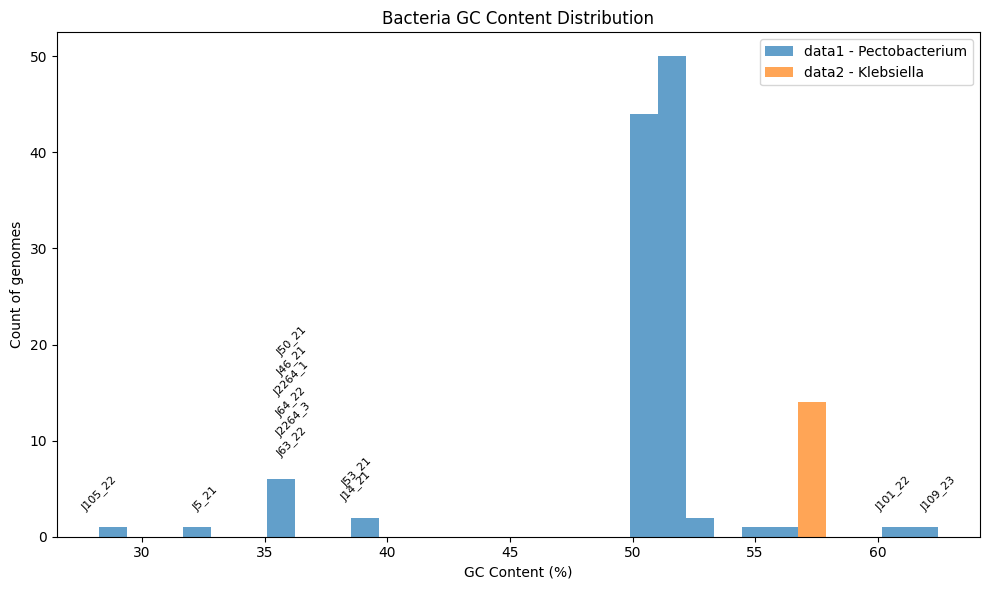

In [2]:
import numpy as np
from Bio.SeqUtils import gc_fraction

def plot_gc_distribution(records, title="Distribution of GC Content"):
    fig, ax = plt.subplots(figsize=(10, 6))

    if len(records) == 2:
        labels = ["data1 - Pectobacterium", "data2 - Klebsiella"]
        gc_contents_list = []
        for record_set in records:
            gc_contents = [gc_fraction(rec.seq) * 100 for rec in record_set]
            gc_contents_list.append(gc_contents)

        ax.hist(gc_contents_list, bins=30, label=labels, stacked=True, alpha=0.7)

    elif len(records) == 1:
        gc_contents = [gc_fraction(rec.seq) * 100 for rec in records[0]]
        gc_contents_list = [gc_contents]
        sns.histplot(gc_contents, bins=30, kde=True, label="Dataset", ax=ax, alpha=0.6)

    else:
        raise ValueError("Expected 1 or 2 sets of records, got {}".format(len(records)))

    gc_contents_long = [gc for sublist in gc_contents_list for gc in sublist]
    bin_counts, bin_edges = np.histogram(gc_contents_long, bins=30)
    bin_annotation_counts = {}
    for record_set in records:
        for rec in record_set:
            gc_value = gc_fraction(rec.seq) * 100
            bin_idx = np.digitize(gc_value, bin_edges, right=False) - 1
            bin_idx = max(0, min(bin_idx, len(bin_edges) - 2))
            bar_height = bin_counts[bin_idx]
            label_step = max(1.5, bar_height * 0.35)
            annotated_count = bin_annotation_counts.get(bin_idx, 0)
            if gc_value < 40 or gc_value > 60:
                print(f"Annotating {rec.id} with GC content {gc_value:.2f}% (Bin {bin_idx}, annotated {annotated_count} times before)")
                ax.annotate(
                    rec.id,
                    xy=(gc_value, bar_height),
                    xytext=(gc_value, bar_height + label_step * (annotated_count + 1)),
                    textcoords="data",
                    rotation=45,
                    fontsize=8,
                    ha="center",
                    va="bottom"
                )
                bin_annotation_counts[bin_idx] = annotated_count + 1



    ax.set_title(title)
    ax.set_xlabel("GC Content (%)")
    ax.set_ylabel("Count of genomes")
    ax.legend()
    plt.tight_layout()
    plt.savefig("../fig/bacteria_gc_distribution.png", dpi=300)
    plt.show()

plot_gc_distribution(records, "Bacteria GC Content Distribution")

### Investigate to see if the Low GC content of Pectobacterium phages is due to a higher relative percentage of plasmids

,source_file,record_id,description,replicon_type,length,gc_content
0,FO3A_23_KMC_reoriented.fna,contig_1,contig_1 [gcode=11] [topology=linear],chromosome,5010387,50.450235
1,J100_22_reoriented.fna,contig_1,contig_1 [gcode=11] [topology=linear],chromosome,5036188,51.882992
2,J100_22_reoriented.fna,contig_2,contig_2 [gcode=11] [topology=linear],plasmid,15783,NaN
3,J101_22_reoriented.fna,contig_1,contig_1 [gcode=11] [topology=linear],chromosome,6445171,60.633442
4,J102_22_reoriented.fna,contig_1,contig_1 [gcode=11] [topology=linear],chromosome,5036868,51.924867


Chromosome entries: 128
Plasmid entries: 152
Unknown entries: 0


replicon_type,chromosome,plasmid,total
source_file,,,
FO3A_23_KMC_reoriented.fna,5010387,0,5010387
J100_22_reoriented.fna,5036188,15783,5051971
J101_22_reoriented.fna,6445171,0,6445171
J102_22_reoriented.fna,5036868,0,5036868
J103_22_reoriented.fna,4025717,1164776,5190493
...,...,...,...
J95_22_reoriented.fna,4964210,0,4964210
J96_22_reoriented.fna,5056856,44900,5101756
J97_22_reoriented.fna,5052391,15468,5067859


replicon_type,chromosome,plasmid
source_file,,
FO3A_23_KMC_reoriented.fna,100.00,0.00
J100_22_reoriented.fna,99.69,0.31
J101_22_reoriented.fna,100.00,0.00
J102_22_reoriented.fna,100.00,0.00
J103_22_reoriented.fna,77.56,22.44
...,...,...
J95_22_reoriented.fna,100.00,0.00
J96_22_reoriented.fna,99.12,0.88
J97_22_reoriented.fna,99.69,0.31


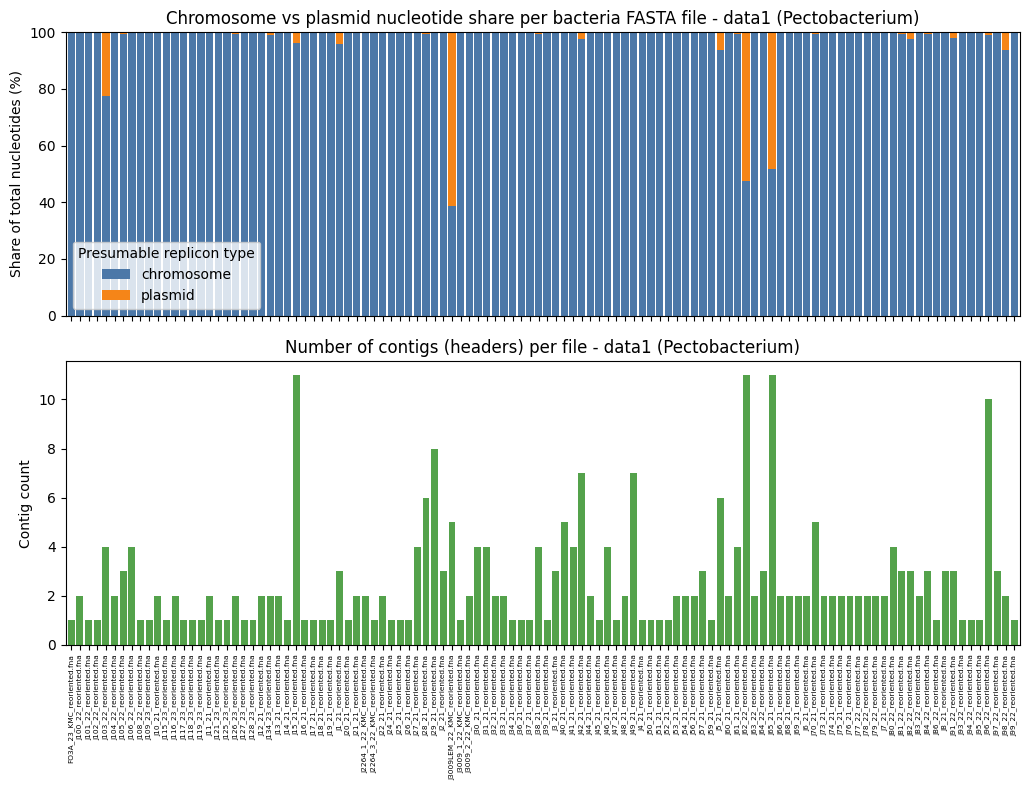

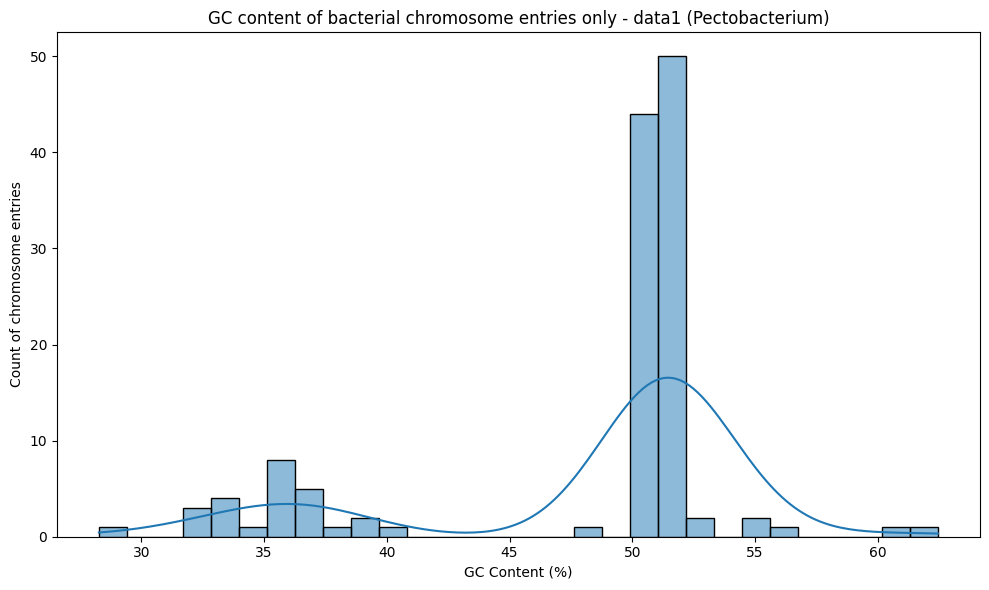

In [18]:
path_to_bact_fasta = raw_data_path+"phagehost_KU/bacteria_fasta/"
bact_files = os.listdir(path_to_bact_fasta)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from Bio.SeqUtils import gc_fraction

def classify_replicon(header):
    if "[location=chromosome]" in header:
        return "chromosome"
    if "[plasmid-name=" in header:
        return "plasmid"
    return "unknown"

chromosome_records = []
plasmid_records = []
unknown_records = []
replicon_rows = []

for fasta_file in sorted(bact_files):
    fasta_path = os.path.join(path_to_bact_fasta, fasta_file)
    records_in_file = list(SeqIO.parse(fasta_path, "fasta"))
    # classify headers first; if unknown, choose largest unknown contig as chromosome
    unknown_indices = []
    for idx, rec in enumerate(records_in_file):
        if classify_replicon(rec.description) == "unknown":
            unknown_indices.append(idx)
    largest_unknown_idx = None
    if unknown_indices:
        sizes = [len(records_in_file[i].seq) for i in unknown_indices]
        largest_unknown_idx = unknown_indices[int(np.argmax(sizes))]

    for idx, record in enumerate(records_in_file):
        replicon_type = classify_replicon(record.description)
        if replicon_type == "unknown":
            # fallback: largest unknown contig -> chromosome, others -> plasmid
            replicon_type = "chromosome" if idx == largest_unknown_idx else "plasmid"
        record_info = {
            "source_file": fasta_file,
            "record_id": record.id,
            "description": record.description,
            "replicon_type": replicon_type,
            "length": len(record.seq),
            "gc_content": gc_fraction(record.seq) * 100 if replicon_type == "chromosome" else np.nan,
        }
        replicon_rows.append(record_info)
        if replicon_type == "chromosome":
            chromosome_records.append(record)
        elif replicon_type == "plasmid":
            plasmid_records.append(record)
        else:
            unknown_records.append(record)

records_dataset1_raw = chromosome_records + plasmid_records + unknown_records
replicon_df = pd.DataFrame(replicon_rows)
display(replicon_df.head())
print(f"Chromosome entries: {len(chromosome_records)}")
print(f"Plasmid entries: {len(plasmid_records)}")
print(f"Unknown entries: {len(unknown_records)}")

replicon_summary = (
    replicon_df[replicon_df["replicon_type"].isin(["chromosome", "plasmid"])]
    .groupby(["source_file", "replicon_type"])["length"]
    .sum()
    .unstack(fill_value=0)
    .reindex(columns=["chromosome", "plasmid"], fill_value=0)
)
replicon_summary["total"] = replicon_summary.sum(axis=1)
replicon_summary_pct = replicon_summary[["chromosome", "plasmid"]].div(replicon_summary["total"], axis=0) * 100
display(replicon_summary.round(2))
display(replicon_summary_pct.round(2))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(max(8, len(replicon_summary_pct) * 0.04 + 6), 8), sharex=True)

# Left: stacked nucleotide share
replicon_summary_pct.sort_index().plot(
    kind="bar",
    stacked=True,
    ax=ax1,
    color=["#4C78A8", "#F58518"],
    width=0.85,
)
ax1.set_ylabel("Share of total nucleotides (%)")
ax1.set_xlabel("Bacteria FASTA file")
ax1.set_title("Chromosome vs plasmid nucleotide share per bacteria FASTA file - data1 (Pectobacterium)")
ax1.legend(title="Presumable replicon type", loc="lower left")
ax1.tick_params(axis="x", rotation=90, labelsize=5.3)

# Right: count of headers (contigs) per file
replicon_counts = replicon_df.groupby("source_file").size()
replicon_counts = replicon_counts.reindex(replicon_summary_pct.sort_index().index).fillna(0)
replicon_counts.plot(kind="bar", ax=ax2, color="#54A24B", width=0.8)
ax2.set_ylabel("Contig count")
ax2.set_xlabel("")
ax2.set_title("Number of contigs (headers) per file - data1 (Pectobacterium)")
ax2.tick_params(axis="x", rotation=90, labelsize=5.3)

plt.tight_layout()
plt.savefig("../fig/bacteria_replicon_composition.png", dpi=300, bbox_inches="tight")
plt.show()

chromosome_gc_df = replicon_df[replicon_df["replicon_type"] == "chromosome"].copy()
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(chromosome_gc_df["gc_content"].dropna(), bins=30, kde=True, ax=ax)
ax.set_title("GC content of bacterial chromosome entries only - data1 (Pectobacterium)")
ax.set_xlabel("GC Content (%)")
ax.set_ylabel("Count of chromosome entries")
plt.tight_layout()
plt.savefig("../fig/bacteria_chromosome_gc_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

## OLD

In [4]:
#Stopping run all
import sys
sys.exit(1)

SystemExit: 1

/net/domus/home/people/s215045/miniconda3/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3755: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
K = 45
bact_kmer_df = fasta_to_kmerdf(raw_data_path+"phagehost_KU/bacteriaKU_cleaned.fasta", k=K)
display(bact_kmer_df.head())
bact_kmer_df = fasta_to_kmerdf(raw_data_path+"phagehost_KU/bacteriaKU_cleaned.fasta", k=K, relative=False)

In [ ]:
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from plotly.subplots import make_subplots

# Interactive heatmap with plotly, with barplot of row sums on the right

import plotly.graph_objects as go

# Create heatmap
heatmap = go.Heatmap(
    z=phage_kmer_df.values*100,  # Scale to percentage
    x=phage_kmer_df.columns,
    y=phage_kmer_df.index,
    colorscale="Turbo",
    colorbar=dict(title=f"Relative {K}mer Frequency (%)"),
    showscale=True
)

# Create barplot for row sums
barplot = go.Bar(
    x=phage_kmer_counts_df.sum(axis=1).values,
    y=phage_kmer_counts_df.index,
    orientation='h',
    marker=dict(color='gray'),
    showlegend=False,
    xaxis='x2',
    yaxis='y2'
)

# Create subplots
fig = make_subplots(
    rows=1, cols=2,
    column_widths=[0.85, 0.15],
    shared_yaxes=True,
    horizontal_spacing=0.00,
    subplot_titles=[f"{K}mer Frequency Heatmap for Phage Sequences", f"{K}mer Counts"]
)

fig.add_trace(heatmap, row=1, col=1)
fig.add_trace(barplot, row=1, col=2)

fig.update_xaxes(title_text=f"{K}mers (Total: {phage_kmer_df.shape[1]})", showticklabels=False, row=1, col=1)
fig.update_xaxes(title_text="Counts", row=1, col=2)
fig.update_yaxes(title_text=f"Phage Sequences (Total: {phage_kmer_df.shape[0]})", row=1, col=1)

fig.update_layout(
    width=1200,
    height=600,
    title_text=f"Distribution of {K}mers Across Phage Sequences, with {K}mer Counts",
    showlegend=False
)

fig.show()

In [ ]:
#Static heatmap with seaborn
plt.figure(figsize=(12,8))
sns.heatmap(phage_kmer_df, cmap="rocket_r")
plt.xlabel(f"{K}mers (Total: {phage_kmer_df.shape[1]})")
plt.ylabel(f"Phage Sequences (Total: {phage_kmer_df.shape[0]})")
plt.title("Kmer Frequency Heatmap for Phage Sequences")